In [248]:
import pandas as pd
import matplotlib.pyplot as plt

df_games = pd.read_csv("C:/Users/esteb/Documents/Esteban/CURSOS/Data-analisis-ComIT_ok/proyecto-final-data-analysis/data/steam_games_clean.csv")
df_copy = df_games.copy()

In [142]:
df_copy.isnull().sum()

app_id                      0
name                        0
release_date                0
price                       0
price_status                0
estimated_owners            0
developers                  0
publishers                  0
genres                      0
categories                  0
tags                        0
positive                    0
negative                    0
average_playtime_forever    0
median_playtime_forever     0
short_description           0
dlc_count                   0
new_app_id                  0
total_ratings               0
good_rating                 2
dtype: int64

In [136]:
df_games.estimated_owners.value_counts()

estimated_owners
20000 - 50000            11258
50000 - 100000            5290
100000 - 200000           3402
200000 - 500000           2801
500000 - 1000000          1124
1000000 - 2000000          704
2000000 - 5000000          393
5000000 - 10000000         119
10000000 - 20000000         49
20000000 - 50000000         29
50000000 - 100000000         7
100000000 - 200000000        4
Name: count, dtype: int64

In [249]:
#Se hace una copia del DB para ajustar la óptica de los registros más relevantes para el análisis de los juegos más exitosos y agilizar el tiempo de porcesamiento en el analisis. Se tomarán los registros con mas de 1.000.000 ventas, significando aproximadamente la mitad de la escala de la que se tienen registros.

df_copy["estimated_owners"] = df_copy.estimated_owners[df_copy.estimated_owners.isin(["1000000 - 2000000", "2000000 - 5000000", "5000000 - 10000000", "10000000 - 20000000", "20000000 - 50000000", "50000000 - 100000000", "100000000 - 200000000"])]

df_copy = df_copy.dropna(subset=["estimated_owners"])

In [250]:
#Creación de columnas de total rating y porcentaje positivo de reseñas.

df_copy["total_ratings"] = df_copy["positive"] + df_copy["negative"]

df_copy["good_rating"] = (((df_copy["positive"] - df_copy["negative"]) / df_copy["total_ratings"]) * 100).round(2)

In [251]:
#Prueba de columna Tags, que tiene la misma logica que genres y categories.

print(df_copy["tags"].head())

print(df_copy["tags"].tail())

26    ["Battle Royale", "Free to Play", "Multiplayer...
38    ["Multiplayer", "Funny", "Online Co-Op", "4 Pl...
40    ["Anime", "JRPG", "Action RPG", "Action", "Onl...
41    ["Physics", "Rogue-like", "Pixel Graphics", "D...
52    ["Strategy", "Turn-Based Tactics", "Turn-Based...
Name: tags, dtype: str
25171    {"Action": 1339, "FPS": 979, "Shooter": 723, "...
25172    {"FPS": 403, "Action": 295, "Classic": 237, "S...
25173    {"Animation & Modeling": 772, "Free to Play": ...
25174    {"RPG": 446, "First-Person": 388, "Action": 36...
25178    {"Atmospheric": 1466, "Post-apocalyptic": 1356...
Name: tags, dtype: str


In [252]:
#Normalización de datos de la comlumna Tags, Genres y Categories. Al revisar las columnas podemos observar que algunos registros tienen forma de diccionario mientras que otros tienen forma de lista. Transformaremos todo para que sea uniforme a listas.

#En una primer instancia, intentamos pasar los registros que parecian ser dict a list, pero la funcion no se aplicaba correctamente porque aún teniendo forma de dict, en realidad solo eran str. Eliminaremos los numeros y los :, los {} y [] del string para poder procesar cada valor y su distribución de forma separada, agrupandolos en listas.

df_copy["tags"] = df_copy["tags"].str.replace(r"[0-9:\{\}\[\]\"]", "", regex=True).str.replace("description", "")
df_copy["tags"] = df_copy["tags"].astype(str).str.split(",").apply(lambda lista: [x.strip().strip('"') for x in lista if x])

df_copy["categories"] = df_copy["categories"].str.replace(r"[0-9:\{\}\[\]\"]", "", regex=True).str.replace("description", "")
df_copy["categories"] = df_copy["categories"].astype(str).str.split(",").apply(lambda lista: [x.strip().strip('"') for x in lista if x])

df_copy["genres"] = df_copy["genres"].str.replace(r"[0-9:\{\}\[\]\"]", "", regex=True).str.replace("description", "")
df_copy["genres"] = df_copy["genres"].astype(str).str.split(",").apply(lambda lista: [x.strip().strip('"') for x in lista if x])

df_copy["genres"] = df_copy["genres"].apply(lambda lista: [x for x in lista if x.lower() != "id"] if isinstance(lista, list) else [])
df_copy["categories"] = df_copy["categories"].apply(lambda lista: [x for x in lista if x.lower() != "id"] if isinstance(lista, list) else [])
df_copy["tags"] = df_copy["tags"].apply(lambda lista: [x for x in lista if x.lower() != "id"] if isinstance(lista, list) else [])



In [253]:
print(df_copy["tags"].head())

print(df_copy["tags"].tail())

26    [Battle Royale, Free to Play, Multiplayer, MOB...
38    [Multiplayer, Funny, Online Co-Op, Player Loca...
40    [Anime, JRPG, Action RPG, Action, Online Co-Op...
41    [Physics, Rogue-like, Pixel Graphics, Difficul...
52    [Strategy, Turn-Based Tactics, Turn-Based Stra...
Name: tags, dtype: object
25171    [Action, FPS, Shooter, Multiplayer, First-Pers...
25172    [FPS, Action, Classic, Sci-fi, Singleplayer, F...
25173    [Animation & Modeling, Free to Play, Video Pro...
25174    [RPG, First-Person, Action, Fantasy, Adventure...
25178    [Atmospheric, Post-apocalyptic, Open World, FP...
Name: tags, dtype: object


In [254]:
#Catalogación por numero de ventas.

best_sellers = df_copy[df_copy.estimated_owners.isin(["10000000 - 20000000", "20000000 - 50000000", "50000000 - 100000000", "100000000 - 200000000", "50000000 - 100000000"])]

top_best_seller1 = df_copy[df_copy.estimated_owners == "100000000 - 200000000"]

top_best_seller2 = df_copy[df_copy.estimated_owners == "50000000 - 100000000"]



In [255]:
#Filtrado de los juegos más vendidos en relación al balance de puntuaciones de usuarios + valoraciones en nuevos lanzamientos.

loved_best_sellers = best_sellers[best_sellers.good_rating >= 90].sort_values(by="good_rating", ascending=False)

new_loved_best_sellers = loved_best_sellers[loved_best_sellers.release_date > "2021-01-01"]

new_loved_best_sellers

,app_id,name,release_date,price,price_status,estimated_owners,developers,publishers,genres,categories,tags,positive,negative,average_playtime_forever,median_playtime_forever,short_description,dlc_count,new_app_id,total_ratings,good_rating
13197,3164500,Schedule I,2025-03-24,19.99,paid,10000000 - 20000000,"[""TVGS""]","[""TVGS""]","[Action, Indie, Simulation, Strategy, Early Ac...","[Single-player, Multi-player, Co-op, Online Co...","[Simulation, Co-op, Crime, Multiplayer, Open W...",200803,3238,1600,1124,From small-time dope pusher to kingpin - manuf...,0,13198,204041,96.83
9299,1966720,Lethal Company,2023-10-23,9.99,paid,10000000 - 20000000,"[""Zeekerss""]","[""Zeekerss""]","[Action, Adventure, Indie, Early Access]","[Single-player, Multi-player, Co-op, Online Co...","[Online Co-Op, Horror, First-Person, Co-op, Su...",473422,13738,1500,730,A co-op horror about scavenging at abandoned m...,0,9300,487160,94.36
16793,526870,Satisfactory,2024-09-10,39.99,paid,10000000 - 20000000,"[""Coffee Stain Studios""]","[""Coffee Stain Publishing""]","[Adventure, Indie, Simulation, Strategy]","[Single-player, Multi-player, Co-op, Online Co...","[Base-Building, Automation, Open World, Multip...",225479,6585,0,0,Satisfactory is a first-person open-world fact...,1,16794,232064,94.32
1876,1086940,Baldur's Gate 3,2023-08-03,59.99,paid,20000000 - 50000000,"[""Larian Studios""]","[""Larian Studios""]","[Adventure, RPG, Strategy]","[Single-player, Multi-player, Co-op, Online Co...","[RPG, Character Customization, Choices Matter,...",736688,23974,7562,4698,"Baldur’s Gate 3 is a story-rich, party-based R...",2,1877,760662,93.70
11151,2358720,Black Myth: Wukong,2024-08-19,59.99,paid,50000000 - 100000000,"[""Game Science""]","[""Game Science""]","[Action, Adventure, RPG]","[Single-player, Steam Achievements, Full contr...","[Mythology, Action RPG, Action, Souls-like, RP...",1111720,38378,3272,2812,Black Myth: Wukong is an action RPG rooted in ...,2,11152,1150098,93.33
13321,3241660,R.E.P.O.,2025-02-26,9.99,paid,10000000 - 20000000,"[""semiwork""]","[""semiwork""]","[Action, Early Access]","[Single-player, Multi-player, Co-op, Online Co...","[Horror, Online Co-Op, Multiplayer, Comedy, Co...",179154,6488,1090,615,An online co-op horror game with up to 6 playe...,0,13322,185642,93.01


In [256]:
#Caracteristicas de cada filtrado. Más popular, mas amado histórico y mejor desempeño en nuevo lanzamiento.

conteo_tags_new_lbs = new_loved_best_sellers["tags"].explode().value_counts()
conteo_cats_new_lbs = new_loved_best_sellers["categories"].explode().value_counts()
conteo_genres_new_lbs = new_loved_best_sellers["genres"].explode().value_counts()

conteo_tags_lbs = loved_best_sellers["tags"].explode().value_counts()
conteo_cats_lbs = loved_best_sellers["categories"].explode().value_counts()
conteo_genres_lbs = loved_best_sellers["genres"].explode().value_counts()

conteo_tags_topbs = top_best_seller1["tags"].explode().value_counts()
conteo_cats_topbs = top_best_seller1["categories"].explode().value_counts()
conteo_genres_topbs = top_best_seller1["genres"].explode().value_counts()


In [257]:
print(f"Caracteristicas de los juegos más populares histórico: \n {conteo_cats_topbs} \n {conteo_genres_topbs} \n {conteo_tags_topbs}")

Caracteristicas de los juegos más populares histórico: 
 categories
Multi-player                    4
Steam Trading Cards             3
In-App Purchases                3
Custom Volume Controls          3
PvP                             2
Online PvP                      2
Co-op                           2
Playable without Timed Input    2
Stereo Sound                    2
Surround Sound                  2
Stats                           2
Remote Play on Phone            2
Remote Play on Tablet           2
Steam Workshop                  2
Camera Comfort                  2
Color Alternatives              2
Valve Anti-Cheat enabled        2
Steam Timeline                  2
Online Co-op                    1
Steam Achievements              1
Full controller support         1
Chat Speech-to-text             1
Partial Controller Support      1
Family Sharing                  1
SteamVR Collectibles            1
Cross-Platform Multiplayer      1
Adjustable Text Size            1
Remote Play on

Los 4 más populares históricos comparten: Multiplayer Online + PvP + Team-based/Co-op + Action + Free to Play.

In [258]:
print(f"Caracteristicas de los juegos más amados histórico: \n {conteo_cats_lbs} \n {conteo_genres_lbs} \n {conteo_tags_lbs}")

Caracteristicas de los juegos más amados histórico: 
 categories
Family Sharing                  23
Single-player                   21
Steam Cloud                     19
Steam Achievements              18
Multi-player                    18
Stereo Sound                    17
Custom Volume Controls          15
Remote Play on Tablet           15
Steam Trading Cards             15
DualShock Controller Support    14
DualSense Controller Support    14
Co-op                           14
Online Co-op                    14
Full controller support         12
Camera Comfort                  12
Playable without Timed Input    12
Save Anytime                    10
Surround Sound                  10
Adjustable Difficulty           10
Remote Play on Phone             9
Steam Workshop                   9
Color Alternatives               9
PvP                              7
Online PvP                       7
Remote Play on TV                7
Valve Anti-Cheat enabled         6
Includes level editor    

Para los más amados históricos, las características son más variadas. Podemos encontrar con mayor frecuencia:

 Action + Singleplayer & Multiplayer + Co-op & Online Co-op. Además ofrecen Remote Play en teléfono, tablet y permiten juego con mando.

In [259]:
print(f"Caracteristicas de los nuevos lanzamientos con mejor desempeño: \n {conteo_cats_new_lbs} \n {conteo_genres_new_lbs} \n {conteo_tags_new_lbs}")

Caracteristicas de los nuevos lanzamientos con mejor desempeño: 
 categories
Single-player                   6
Stereo Sound                    6
Family Sharing                  6
Multi-player                    5
Co-op                           5
Online Co-op                    5
Custom Volume Controls          5
Steam Cloud                     5
Steam Achievements              4
Camera Comfort                  4
Playable without Timed Input    4
Adjustable Text Size            3
Save Anytime                    3
Surround Sound                  3
Partial Controller Support      2
Cross-Platform Multiplayer      2
Color Alternatives              2
Adjustable Difficulty           2
DualShock Controller Support    2
DualSense Controller Support    2
Full controller support         2
Steam Trading Cards             2
Remote Play on Tablet           1
LAN Co-op                       1
Subtitle Options                1
Remote Play on TV               1
Remote Play Together            1
Name:

Nuevos Lanzamientos con mejor desempeño presentan en mayor porcentaje, aún siendo bastante variados: 

Action + SinglePlayer & Multiplayer + Co-op & Online Co-op. 

Tambien "Early-access" tiene una frecuencia en más de un juego del listado, lo que podría indicarnos que son juegos que son esperados, lo que pone mayor peso en el marketing y el "hype" que se puede generar en base al desarrollo del juego.

TOP MAS DESCARGADOS HISTORICO (+100M descargas)

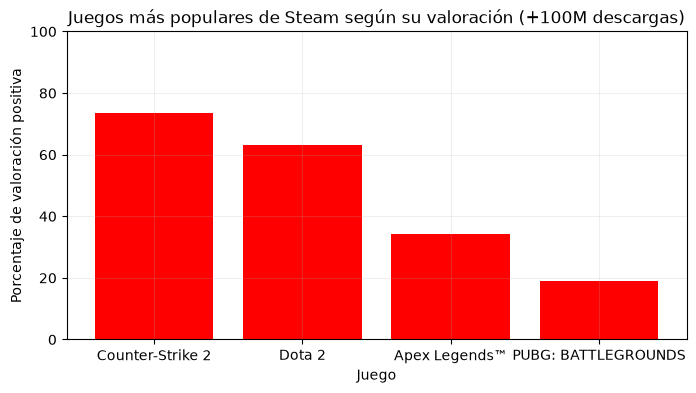

In [296]:
#Visualización juegos más populares segun su valoración positiva. ¿Qué juegos son los más populares historicamente?
top_best_seller1 = top_best_seller1.sort_values(by="good_rating", ascending=False)

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(top_best_seller1.name, top_best_seller1.good_rating, color="red")
ax.set_title("Juegos más populares de Steam según su valoración (+100M descargas)")
ax.set_xlabel("Juego")
ax.set_ylabel("Porcentaje de valoración positiva")
ax.set_ylim(0, 100)
ax.grid(alpha=0.2)
plt.show()

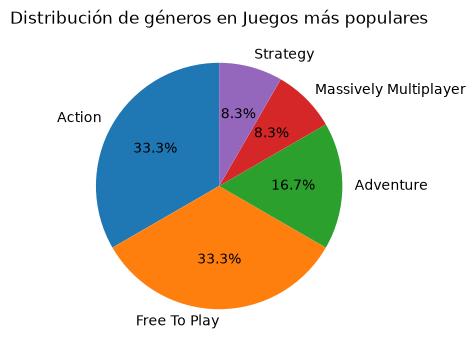

In [260]:
#Géneros de los más vendidos en %

porcentaje_genre_topbs = ((conteo_genres_topbs / len(conteo_genres_topbs)) * 100).round(2)

porcentaje_genre_topbs
conteo_genres_topbs

fig, ax = plt.subplots(figsize = (8,4))
ax.pie(conteo_genres_topbs.values, labels=conteo_genres_topbs.index,  autopct="%1.1f%%", startangle=90)
ax.set_title("Distribución de géneros en Juegos más populares")
plt.show()

TOP MEJOR VALORADOS HISTORICO (+10M descargas)

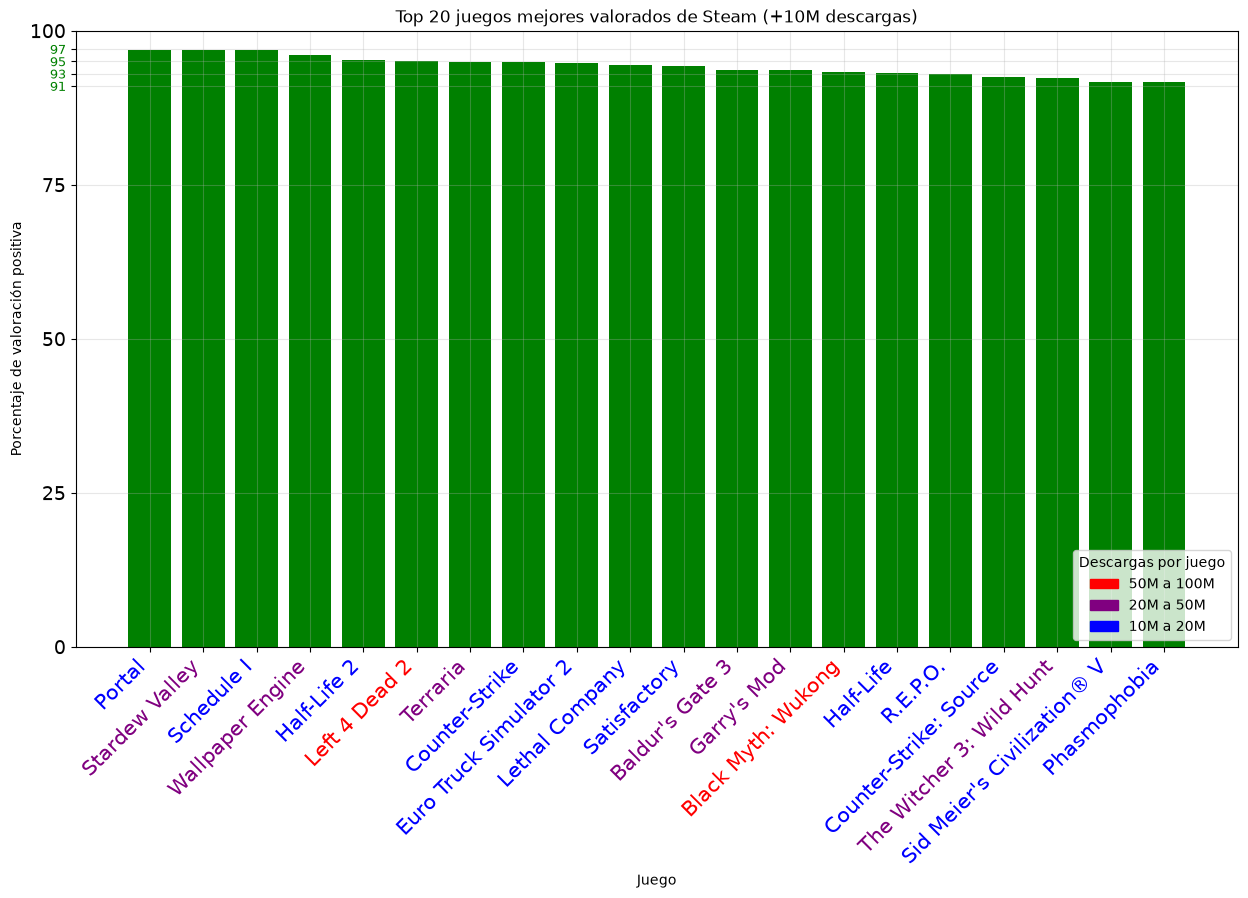

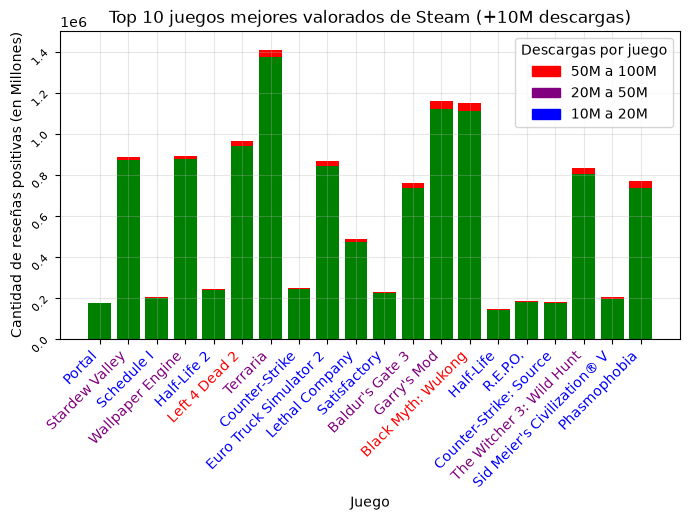

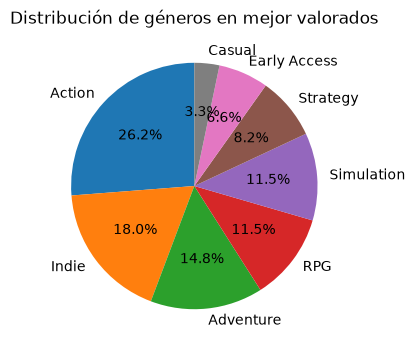

In [304]:
#Visualización juegos mejores valorados con más de 10M descargas según valoración. ¿Que juegos son los más gustados históricamentes?
import matplotlib.patches as mpatches
loved_best_sellers_grph = loved_best_sellers.sort_values(by="good_rating", ascending=False).head(20)

fig, ax = plt.subplots(figsize = (15,8))
ax.bar(loved_best_sellers_grph.name, loved_best_sellers_grph.good_rating, color="green")
ax.set_title("Top 20 juegos mejores valorados de Steam (+10M descargas)")
ax.set_xlabel("Juego")
ax.set_ylabel("Porcentaje de valoración positiva")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

ax.set_yticks([0,25,50,75,91, 93, 95, 97, 100])
plt.xticks(rotation=45, ha="right")

for label in ax.get_yticklabels():
    if label.get_text() >= "90":
        label.set_fontsize(9)
        label.set_color("green")
    else:
        label.set_fontsize(14)

for label in ax.get_xticklabels():
    label.set_fontsize(15)
    texto = label.get_text()
    descargas = df_copy.loc[df_copy["name"] == texto, "estimated_owners"].values[0]

    if descargas == "50000000 - 100000000":
        label.set_color("red")
    elif descargas == "100000000 - 200000000":
        label.set_color("orange")
    elif descargas == "20000000 - 50000000":
        label.set_color("purple")
    elif descargas == "10000000 - 20000000":
        label.set_color("blue")
    else:
        label.set_color("black")

rojo = mpatches.Patch(color="red", label="50M a 100M")
azul = mpatches.Patch(color="blue", label="10M a 20M")
violeta = mpatches.Patch(color="purple", label="20M a 50M")

ax.legend(handles=[rojo, violeta,azul], title = "Descargas por juego", loc="lower right")

plt.show()

#Segun cantidad neta de valoración positiva.

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(loved_best_sellers_grph.name, loved_best_sellers_grph.positive, color="green",label="positivas")
ax.bar(loved_best_sellers_grph.name, loved_best_sellers_grph.negative, bottom= loved_best_sellers_grph.positive, color="red", label="negativas")
ax.set_title("Top 10 juegos mejores valorados de Steam (+10M descargas)")
ax.set_xlabel("Juego")
ax.set_ylabel("Cantidad de reseñas positivas (en Millones)")
ax.set_ylim(0, 1500000)
ax.grid(alpha=0.3)


plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=45, ha="right", fontsize=8)

for label in ax.get_xticklabels():
    texto = label.get_text()
    descargas = df_copy.loc[df_copy["name"] == texto, "estimated_owners"].values[0]

    if descargas == "50000000 - 100000000":
        label.set_color("red")
    elif descargas == "100000000 - 200000000":
        label.set_color("orange")
    elif descargas == "20000000 - 50000000":
        label.set_color("purple")
    elif descargas == "10000000 - 20000000":
        label.set_color("blue")
    else:
        label.set_color("black")

rojo = mpatches.Patch(color="red", label="50M a 100M")
azul = mpatches.Patch(color="blue", label="10M a 20M")
violeta = mpatches.Patch(color="purple", label="20M a 50M")

ax.legend(handles=[rojo, violeta,azul], title = "Descargas por juego")

plt.show()

#Distribución de géneros en todos los mejor valorados best-seller

conteo_genres_lbs_grph = conteo_genres_lbs[conteo_genres_lbs.values > 1]


fig, ax = plt.subplots(figsize = (8,4))
ax.pie(conteo_genres_lbs_grph.values, labels=conteo_genres_lbs_grph.index,  autopct="%1.1f%%", startangle=90)
ax.set_title("Distribución de géneros en mejor valorados")
plt.show()


In [273]:
loved_best_sellers.shape

(24, 20)

In [309]:
df_copy[df_copy.app_id == 105600]

,app_id,name,release_date,price,price_status,estimated_owners,developers,publishers,genres,categories,tags,positive,negative,average_playtime_forever,median_playtime_forever,short_description,dlc_count,new_app_id,total_ratings,good_rating
24037,105600,Terraria,2011-05-16,9.99,paid,20000000 - 50000000,"[""Re-Logic""]","[""Re-Logic""]","[Action, Adventure, Indie, RPG]","[Single-player, Multi-player, PvP, Online PvP,...","[Open World Survival Craft, Sandbox, Survival,...",1373979,35494,0,0,"Dig, fight, explore, build! Nothing is impossi...",2,24038,1409473,94.96


NUEVOS LANZAMIENTOS EXITOSOS (Valoracion positiva + +10M descargas)

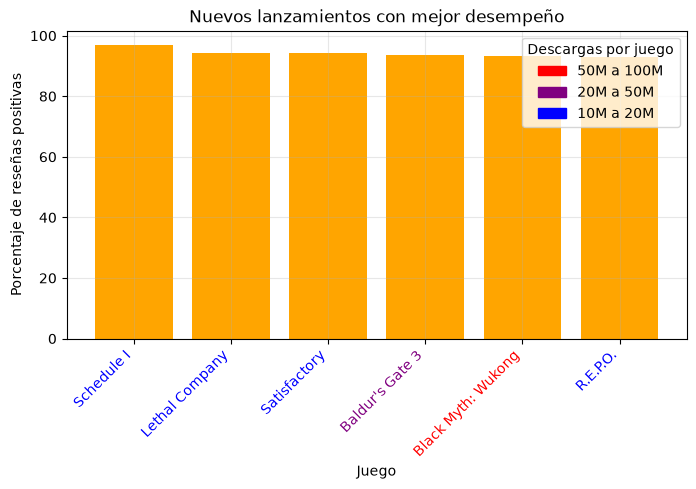

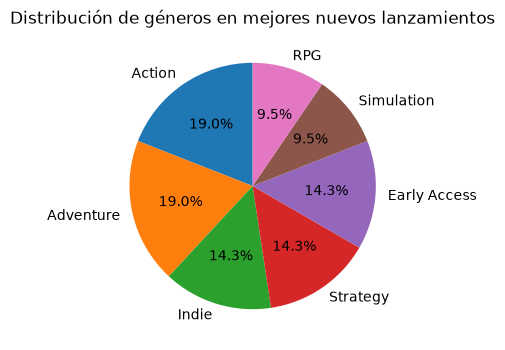

 Nuevos lanzamientos con mejor desempeño: 
 13197            Schedule I
9299         Lethal Company
16793          Satisfactory
1876        Baldur's Gate 3
11151    Black Myth: Wukong
13321              R.E.P.O.
Name: name, dtype: str13197    2025-03-24
9299     2023-10-23
16793    2024-09-10
1876     2023-08-03
11151    2024-08-19
13321    2025-02-26
Name: release_date, dtype: str


In [295]:
#Visualización de juegos nuevos, lanzados a partir de 2022 que alcanzaron el exito en ventas y buenas puntuaciones. ¿Que juegos recientes tuvieron éxito en el mercado actual?

new_loved_best_sellers_grph = new_loved_best_sellers.sort_values(by="good_rating", ascending=False)

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(new_loved_best_sellers_grph.name, new_loved_best_sellers_grph.good_rating, color="orange")
ax.set_title("Nuevos lanzamientos con mejor desempeño")
ax.set_xlabel("Juego")
ax.set_ylabel("Porcentaje de reseñas positivas")
ax.grid(alpha=0.3)

for label in ax.get_xticklabels():
    texto = label.get_text()
    descargas = df_copy.loc[df_copy["name"] == texto, "estimated_owners"].values[0]

    if descargas == "50000000 - 100000000":
        label.set_color("red")
    elif descargas == "100000000 - 200000000":
        label.set_color("orange")
    elif descargas == "20000000 - 50000000":
        label.set_color("purple")
    elif descargas == "10000000 - 20000000":
        label.set_color("blue")
    else:
        label.set_color("black")

rojo = mpatches.Patch(color="red", label="50M a 100M")
azul = mpatches.Patch(color="blue", label="10M a 20M")
violeta = mpatches.Patch(color="purple", label="20M a 50M")

ax.legend(handles=[rojo, violeta,azul], title = "Descargas por juego")

plt.xticks(rotation=45, ha="right")

plt.show()

fig, ax = plt.subplots(figsize = (8,4))
ax.pie(conteo_genres_new_lbs.values, labels=conteo_genres_new_lbs.index,  autopct="%1.1f%%", startangle=90)
ax.set_title("Distribución de géneros en mejores nuevos lanzamientos")
plt.show()

print(f" Nuevos lanzamientos con mejor desempeño: \n {new_loved_best_sellers_grph.name}{new_loved_best_sellers_grph.release_date}")


In [302]:
loved_best_sellers.developers.value_counts()

developers
["Valve"]                                            6
["ConcernedApe"]                                     1
["TVGS"]                                             1
["Wallpaper Engine Team"]                            1
["Re-Logic"]                                         1
["SCS Software"]                                     1
["Zeekerss"]                                         1
["Coffee Stain Studios"]                             1
["Larian Studios"]                                   1
["Facepunch Studios"]                                1
["Game Science"]                                     1
["semiwork"]                                         1
["CD PROJEKT RED"]                                   1
["Firaxis Games", "Aspyr (Mac)", "Aspyr (Linux)"]    1
["Kinetic Games"]                                    1
["Endnight Games Ltd"]                               1
["FromSoftware, Inc."]                               1
["Klei Entertainment"]                               1

In [278]:
new_loved_best_sellers["app_id"]

13197    3164500
9299     1966720
16793     526870
1876     1086940
11151    2358720
13321    3241660
Name: app_id, dtype: int64

In [291]:
top_best_seller1.app_id



2730     1172470
16336     578080
24777        570
24780        730
Name: app_id, dtype: int64

In [283]:
print(loved_best_sellers.app_id)


24773        400
19349     413150
13197    3164500
18734     431960
24769        220
24776        550
24037     105600
24760         10
24479     227300
9299     1966720
16793     526870
1876     1086940
24875       4000
11151    2358720
24766         70
13321    3241660
24770        240
23235     292030
24717       8930
14259     739630
22271     242760
20210     814380
21677     322330
22233     239140
Name: app_id, dtype: int64


In [299]:
df_copy[df_copy.app_id == 105600]

,app_id,name,release_date,price,price_status,estimated_owners,developers,publishers,genres,categories,tags,positive,negative,average_playtime_forever,median_playtime_forever,short_description,dlc_count,new_app_id,total_ratings,good_rating
24037,105600,Terraria,2011-05-16,9.99,paid,20000000 - 50000000,"[""Re-Logic""]","[""Re-Logic""]","[Action, Adventure, Indie, RPG]","[Single-player, Multi-player, PvP, Online PvP,...","[Open World Survival Craft, Sandbox, Survival,...",1373979,35494,0,0,"Dig, fight, explore, build! Nothing is impossi...",2,24038,1409473,94.96
